In [45]:
import numpy as np
import matplotlib.pyplot as plt
import util.functions as functions
from models.FNO import CAPE_FNO, FNO
import pybamm
import flax

In [46]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
from util.postprocess import filter_anode_cathode, calc_error_metrics, calc_error_metrics_all

In [47]:
family = "GRF"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
random_seed = 42
test_ratio = 0.1

train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)

In [48]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

### Anode data ###
train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])
train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])
train_D_anode = np.array(train_data["Dan"])
test_D_anode = np.array(test_data["Dan"])

###Cathode data ###
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])
train_D_cathode = np.array(train_data["Dca"])
test_D_cathode = np.array(test_data["Dca"])

In [49]:
# Check if train_I and test_I have any overlapping elements
overlap = np.intersect1d(train_I, test_I)
if overlap.size == 0:
    print("train_I and test_I are distinct (no overlap).")
else:
    print(f"train_I and test_I have {overlap.size} overlapping elements.")

train_I and test_I have 2 overlapping elements.


In [50]:
import numpy as np

def any_common_row(A: np.ndarray, B: np.ndarray) -> bool:
    """
    Return True if any row of A (shape (x, 75)) is identical
    to any row of B (shape (y, 75)).
    """
    if A.shape[1] != B.shape[1]:
        raise ValueError("Second dimension must be equal (both 75).")

    # (x, 1, 75) compared with (y, 75) → (x, y, 75)
    equal_all_coords = (A[:, None, :] == B)            # element-wise
    row_matches      = equal_all_coords.all(axis=2)    # collapse 75 → True/False per row pair
    return row_matches.any(), np.where(row_matches)                           # at least one True?


In [51]:
test_D_anode.shape

(3300,)

In [52]:
boll, id = any_common_row(test_D_anode.reshape(-1,1), train_D_anode.reshape(-1,1))

In [54]:
train_I[i]

NameError: name 'i' is not defined

In [ ]:
test_I[1804]

array([3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45,
       3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45, 3.45])

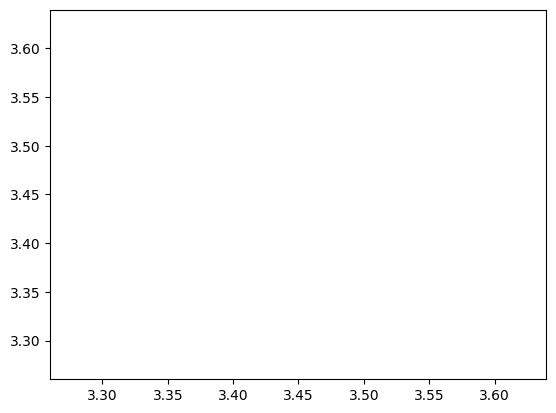

In [ ]:
import matplotlib.pyplot as plt
plt.plot(test_I[id[0][0]], train_I[id[1][0]])